In [1]:
# Session 14
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_cp_dataset.csv')

In [3]:
sample_materials = df['formula'].unique()[:5]

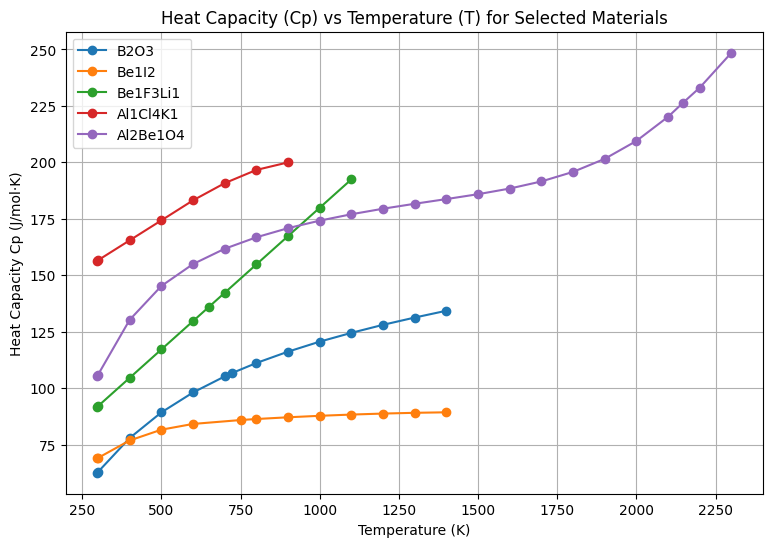

In [4]:
plt.figure(figsize=(9, 6))
for mat in sample_materials:
    subset = df[df['formula'] == mat]
    plt.plot(subset['T'], subset['Cp'], marker='o', label=mat)

plt.title('Heat Capacity (Cp) vs Temperature (T) for Selected Materials')
plt.xlabel('Temperature (K)')
plt.ylabel('Heat Capacity Cp (J/mol·K)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def classify_family(formula):
    if 'O' in formula and 'C' not in formula and 'N' not in formula:
        return 'Oxide'
    elif 'C' in formula:
        return 'Carbide'
    elif 'N' in formula:
        return 'Nitride'
    else:
        return 'Other'

df['family'] = df['formula'].apply(classify_family)
df_grouped = df[df['family'].isin(['Oxide', 'Carbide', 'Nitride'])]
family_stats = df_grouped.groupby(['family', 'T'])['Cp'].agg(['mean', 'std']).reset_index()